# 04 — Fairness Audit

Audit the chosen XGBoost model at the cost-based threshold by SEX, AGE band, and MARRIAGE. Protected attributes are excluded from model features and retained only for audit.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..', 'src').resolve()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from credit_risk import data, fairness, threshold

MODELS_DIR = Path('..', 'models')
FIG_DIR = Path('..', 'reports', 'figures')
TABLE_DIR = Path('..', 'reports', 'tables')
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

raw = data.load_raw()
train_df, test_df = data.train_test_split_data(raw)
feats = data.feature_columns(raw)
X_train, y_train = train_df[feats], train_df[data.TARGET]
X_test, y_test = test_df[feats], test_df[data.TARGET]
protected_test = test_df[list(data.PROTECTED)].copy()

xgb_model = xgb.XGBClassifier()
xgb_model.load_model(MODELS_DIR / 'xgboost_model.json')
score_xgb = xgb_model.predict_proba(X_test)[:, 1]
chosen_threshold = threshold.optimal_threshold(y_test.to_numpy(), score_xgb).best_threshold
print(f'test_rows={len(test_df):,}')
print(f'chosen_threshold={chosen_threshold:.3f}')


test_rows=7,500
chosen_threshold=0.151


In [2]:
def group_labels(frame):
    return {
        'SEX': frame['SEX'].map({1: 'Male', 2: 'Female'}),
        'AGE band': fairness.bucket_age(frame['AGE']).astype(str),
        'MARRIAGE': frame['MARRIAGE'].map({1: 'married', 2: 'single', 3: 'other'}).fillna('undocumented'),
    }

all_tables = []
for attribute, labels in group_labels(protected_test).items():
    table = fairness.approval_fairness_table(
        y_test.to_numpy(), score_xgb, chosen_threshold, labels
    )
    table.insert(0, 'attribute', attribute)
    table['tpr_gap_for_attribute'] = fairness.true_positive_rate_gap(table)
    all_tables.append(table)

fairness_audit = pd.concat(all_tables, ignore_index=True)
fairness_audit.to_csv(TABLE_DIR / 'fairness_audit_chosen_threshold.csv', index=False)
print(fairness_audit.round(4).to_string(index=False))
print('\nAny disparate-impact flags below 0.8?')
print(fairness_audit.loc[fairness_audit['di_flag_below_0_8'], ['attribute', 'group', 'disparate_impact_ratio']].round(3).to_string(index=False))


attribute        group    n  approval_rate  actual_default_rate  mean_predicted_pd  calibration_error  true_positive_rate  disparate_impact_ratio  di_flag_below_0_8  tpr_gap_for_attribute
      SEX       Female 4605         0.5496               0.2056             0.2130             0.0074              0.7730                  1.0000              False                 0.0023
      SEX         Male 2895         0.5026               0.2459             0.2366            -0.0093              0.7753                  0.9144              False                 0.0023
 AGE band        26-35 3273         0.5622               0.1937             0.2103             0.0166              0.7744                  1.0000              False                 0.1314
 AGE band        36-45 2114         0.5445               0.2332             0.2167            -0.0165              0.7525                  0.9685              False                 0.1314
 AGE band        46-55  953         0.5215               0.2

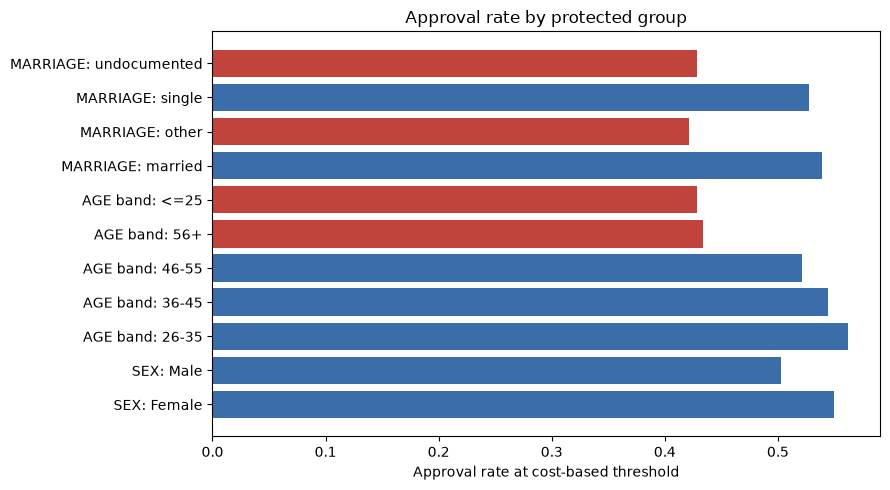

In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = fairness_audit.copy()
plot_data['label'] = plot_data['attribute'] + ': ' + plot_data['group'].astype(str)
colors = np.where(plot_data['di_flag_below_0_8'], '#C1443C', '#3B6EA8')
ax.barh(plot_data['label'], plot_data['approval_rate'], color=colors)
ax.set_xlabel('Approval rate at cost-based threshold')
ax.set_ylabel('')
ax.set_title('Approval rate by protected group')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fairness_approval_rates.png', dpi=160)
plt.show()


## Proxy-effect test

The production candidate excludes SEX, AGE, MARRIAGE, and EDUCATION. To test whether exclusion removes disparity, compare it with a model that includes those fields using the same decision threshold.

In [4]:
protected_features = list(data.PROTECTED)
all_features = feats + protected_features
xgb_with_protected = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=data.SEED,
    eval_metric='logloss',
).fit(train_df[all_features], y_train)
score_with_protected = xgb_with_protected.predict_proba(test_df[all_features])[:, 1]

proxy_rows = []
for model_name, scores in {
    'protected_excluded_candidate': score_xgb,
    'protected_included_test': score_with_protected,
}.items():
    for attribute, labels in group_labels(protected_test).items():
        table = fairness.approval_fairness_table(y_test.to_numpy(), scores, chosen_threshold, labels)
        proxy_rows.append(
            {
                'model': model_name,
                'attribute': attribute,
                'min_disparate_impact_ratio': table['disparate_impact_ratio'].min(),
                'any_di_flag_below_0_8': bool(table['di_flag_below_0_8'].any()),
                'tpr_gap': fairness.true_positive_rate_gap(table),
            }
        )
proxy = pd.DataFrame(proxy_rows)
proxy.to_csv(TABLE_DIR / 'proxy_attribute_test.csv', index=False)
print(proxy.round(4).to_string(index=False))

candidate_flags = proxy.query("model == 'protected_excluded_candidate' and any_di_flag_below_0_8")
if len(candidate_flags):
    print('\nResult: excluding protected attributes does not remove all disparities; flagged approval-rate gaps remain in the candidate model, so repayment and balance variables still carry correlated risk/proxy signal.')
else:
    print('\nResult: excluding protected attributes removes four-fifths-rule approval-rate flags in this test split, though monitoring remains required.')


                       model attribute  min_disparate_impact_ratio  any_di_flag_below_0_8  tpr_gap
protected_excluded_candidate       SEX                      0.9144                  False   0.0023
protected_excluded_candidate  AGE band                      0.7618                   True   0.1314
protected_excluded_candidate  MARRIAGE                      0.7818                   True   0.3077
     protected_included_test       SEX                      0.8565                  False   0.0332
     protected_included_test  AGE band                      0.7012                   True   0.0825
     protected_included_test  MARRIAGE                      0.5622                   True   0.8084

Result: excluding protected attributes does not remove all disparities; flagged approval-rate gaps remain in the candidate model, so repayment and balance variables still carry correlated risk/proxy signal.
